# Reverse diffusion on $S^2$

Constructing an initial smiley face shaped distribution on $S^2$ and generating points from it using reverse diffusion and the exact score. Later, training a neural net to learn the score and reproduce the initial distribution.

In [3]:
#Run initializing code containing globals and function definitions

%run smiley.py

## Constructing and diffusing target distribution

### Sample points from initial distribution

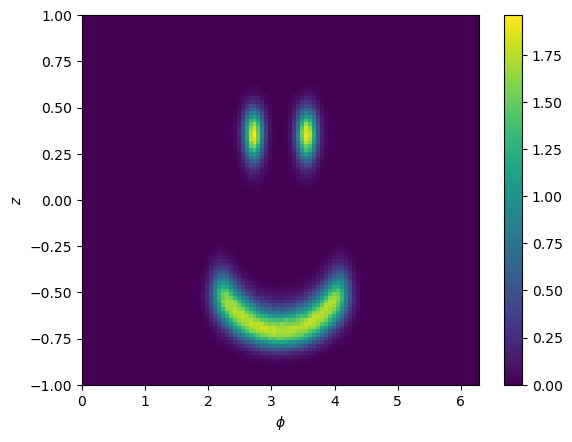

In [ ]:
samples0 = smileySample(8*nSmile*10000)
plotSphereHist(samples0)

### Diffusing distribution

Calculate both the diffused distribution and the diffused samples and compare. Demonstrate that the distribution is close to uniform at $t=4$ with total variation (TV) distance $2\times 10^{-4}$.

Diffuse samples over a range of times

In [ ]:
# times to diffuse

timesU = np.linspace(0,1,5)
print(timesU)
timesTau = sde.tauFromU(timesU,t0,tF)
print(timesTau)

[0.   0.25 0.5  0.75 1.  ]
[0.         0.02159979 0.13650972 0.74782562 4.        ]


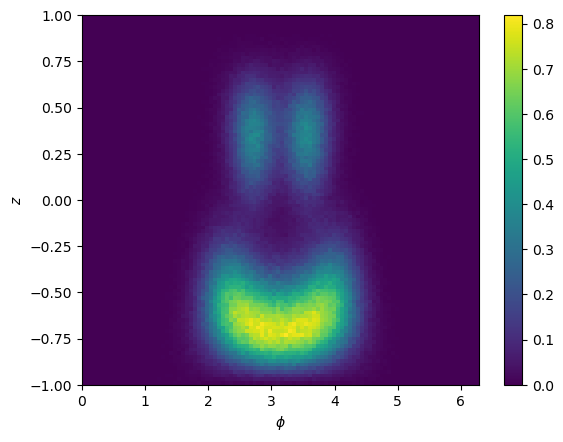

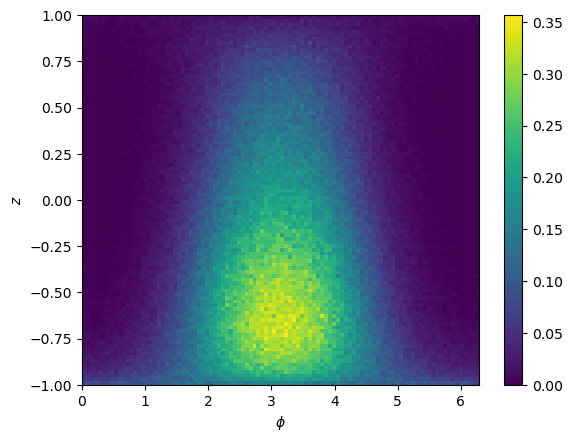

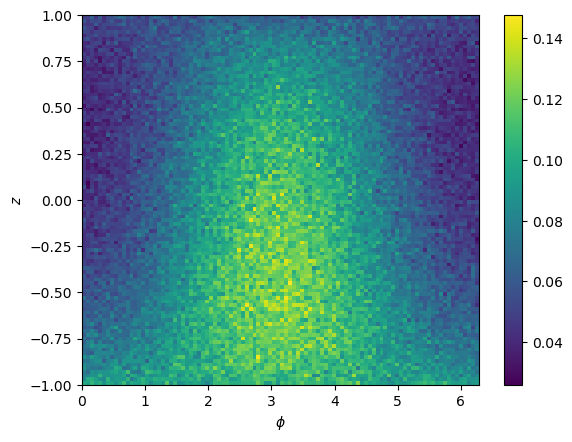

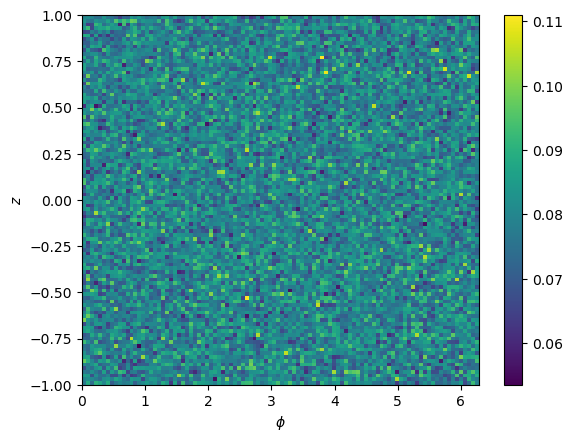

In [ ]:
# Plotting diffused samples

for i in range(len(timesTau)-1):
    plotSphereHist(sphere.hk(samples0, timesTau[i+1]))

The sample at $t=4$ looks nearly uniform. How bad is the error if we approximate by uniform?

In [ ]:
# Calculate TV distance between uniform and t=4 smiley

nZ = 1001
nPhi = 1000

phi = np.linspace(0, 2*np.pi, nPhi, endpoint=False)
z = np.linspace(-1, 1, nZ)[:, None]
sinTh = np.sqrt(1 - z**2)

vX = np.cos(phi)*sinTh
vY = np.sin(phi)*sinTh
vZ = np.broadcast_to(z, (nZ, nPhi))
v = np.stack([vX, vY, vZ], axis=-1)

values = smileyDist(v, 4)

#Take absolute error from uniform dist 1/area. TV distance has an overall factor of 1/2
integrand = .5*np.abs(values-1/(4*np.pi))
integrandZ = 2*np.pi*integrand.mean(1)

#Trapezoidal rule
dz = 2/(nZ-1)
integral = dz*(.5*(integrandZ[0]+integrandZ[-1])+integrandZ[1:-1].sum())
print(f"TV distance from uniform at t=4 = {integral.item()}")

TV distance from uniform at t=4 = 0.00019461531468021066


## Solving ODE for reverse diffusion

Construct score field for smiley face distribution diffused to arbitrary $t$. Test forward Euler for various time stepping schemes, using TV distance as a diagnostic. It turns out linear time steps in log t does well. Then test an RK2 method on the sphere by Leung, Chau, Lee (2024).

### Euler integration of reverse diffusion ODE

In [ ]:
#construct reverse times linear in the square root of t
nSteps = 100
du = 2/nSteps
reverseTimesLin = []
for i in range(0,nSteps+1):
    reverseTimesLin.append((2-i*du)**2)

In [ ]:
#linear spacing in log t
nSteps = 100
reverseTimes = []
for i in range(nSteps + 1):
    a = i/nSteps
    tEff = np.exp((1-a)*np.log(t0 + 4) + a*np.log(t0))
    reverseTimes.append(tEff - t0)

In [ ]:
#sample at t=4 from uniform
nBatch = 100000
samples4 = sphere.normalize(np.random.normal(0,1,(nBatch,3)))

In [ ]:
from tqdm.notebook import tqdm

samplesLin = samples4.copy()
for i in tqdm(range(len(reverseTimesLin)-1)):
    dt = reverseTimesLin[i]-reverseTimesLin[i+1]
    samplesLin = sde.eulerStep(samplesLin, reverseTimesLin[i], dt, scoreSmiley)

plotSphereHist(samplesLin)

In [ ]:
samples = samples4.copy()
for i in tqdm(range(len(reverseTimes)-1)):
    dt = reverseTimes[i]-reverseTimes[i+1]
    samples = sde.eulerStep(samples, reverseTimes[i], dt, scoreSmiley)

plotSphereHist(samples)

### Total variation (TV) distance of ODE results from initial distribution

In [ ]:
nPhi = 100
print(f"TV distance of ODE, linear in tau timesteps")
print(f"nSteps: {nSteps},  nBatch: {nBatch},  nPhi: {nPhi}")
print(distHist(samplesLin, nPhi))

TV distance of ODE, linear in tau timesteps
nSteps: 100,  nBatch: 100000,  nPhi: 100
0.10818310416207076


In [ ]:
nPhi = 100
print(f"TV distance of ODE, linear in u timesteps")
print(f"nSteps: {nSteps},  nBatch: {nBatch},  nPhi: {nPhi}")
print(distHist(samples, nPhi))

TV distance of ODE, linear in u timesteps
nSteps: 100,  nBatch: 100000,  nPhi: 100
0.08956794203209205


Compare the error of the ODE above with the error of a directly sampled distribution below

In [ ]:
samples0 = smileySample(nBatch)
print(f"TV distance of histogram of direct samples")
print(f"nBatch: {nBatch},  nPhi: {nPhi}")
print(distHist(samples0, nPhi))

TV distance of histogram of direct samples
nBatch: 100000,  nPhi: 100
0.07828160343195316


In [ ]:
# A few more samples
samples0 = smileySample(nBatch)
print(distHist(samples0, nPhi))
samples0 = smileySample(nBatch)
print(distHist(samples0, nPhi))
samples0 = smileySample(nBatch)
print(distHist(samples0, nPhi))
samples0 = smileySample(nBatch)
print(distHist(samples0, nPhi))

0.08008092112191237
0.07997662043899605
0.08170480219140931
0.08195314829490224


### STVDRK2 method

An RK2 method on $S^2$ taken from Leung, Chau, Lee (2024). Basically Heun's method on $S^2$.

In [ ]:
#linear spacing in u, 50 time steps (2 score evaluations each)
nBatch = 100000
nSteps = 50
reverseTimes = []
for i in range(nSteps + 1):
    a = i/nSteps
    tEff = np.exp((1-a)*np.log(t0 + 4) + a*np.log(t0))
    reverseTimes.append(tEff - t0)

samplesRK2 = samples4.copy()
for i in tqdm(range(len(reverseTimes)-1)):
    dt = reverseTimes[i]-reverseTimes[i+1]
    samplesRK2 = sde.rk2Step(samplesRK2, reverseTimes[i], dt, scoreSmiley)

plotSphereHist(samplesRK2)

In [ ]:
nPhi = 100
print(f"TV distance of ODE (RK2), linear in u timesteps")
print(f"nSteps: {nSteps},  nBatch: {nBatch},  nPhi: {nPhi}")
print(distHist(samplesRK2, nPhi))

TV distance of ODE (RK2), linear in u timesteps
nSteps: 50,  nBatch: 100000,  nPhi: 100
0.08068209151048962


Within the range of the TV distance of the direct samples. Let's try going to larger nBatch.

In [ ]:
nBatch = 1000000
samples4 = sphere.normalize(np.random.normal(0,1,(nBatch,3)))

samplesRK2Large = samples4.copy()
for i in tqdm(range(len(reverseTimes)-1)):
    dt = reverseTimes[i]-reverseTimes[i+1]
    samplesRK2Large = sde.rk2Step(samplesRK2Large, reverseTimes[i], dt, scoreSmiley)

In [ ]:
plotSphereHist(samplesRK2Large)

nPhi = 200
print(f"TV distance of ODE (RK2), linear in u timesteps")
print(f"nSteps: {nSteps},  nBatch: {nBatch},  nPhi: {nPhi}")
print(distHist(samplesRK2Large, nPhi))

TV distance is indistinguishable from direct samples:

In [ ]:
nPhi = 200
nBatch = 1000000
samples0 = smileySample(nBatch)
print(f"TV distance of histogram of direct samples")
print(f"nBatch: {nBatch},  nPhi: {nPhi}")
print(distHist(samples0, nPhi))

TV distance of histogram of direct samples
nBatch: 1000000,  nPhi: 200
0.04398168420499351


In [ ]:
# A few more samples
samples0 = smileySample(nBatch)
print(distHist(samples0, nPhi))
samples0 = smileySample(nBatch)
print(distHist(samples0, nPhi))
samples0 = smileySample(nBatch)
print(distHist(samples0, nPhi))
samples0 = smileySample(nBatch)
print(distHist(samples0, nPhi))

0.0443219059778094
0.04416325843258872
0.043479989131646274
0.043344400258128093


## Euler-Maruyama and predictor/corrector schemes

Testing stochastic reverse diffusion methods. These are shown to do worse than the ODE for the exact score, but later on are shown to do better for a trained model with an imperfectly learned score. The direct Euler-Maruyama does slightly better here than an predictor-corrector scheme involving Langevin at a single time.

#### Euler-Maruyama

In [ ]:
#linear spacing in u, 100 time steps (1 score evaluation each)
nBatch = 100000
nSteps = 100
reverseTimes = []
for i in range(nSteps + 1):
    a = i/nSteps
    tEff = np.exp((1-a)*np.log(t0 + 4) + a*np.log(t0))
    reverseTimes.append(tEff - t0)

samplesSDE = samples4.copy()
for i in tqdm(range(len(reverseTimes)-1)):
    dt = reverseTimes[i]-reverseTimes[i+1]
    samplesSDE = sde.eulerMaruyamaStep(samplesSDE, reverseTimes[i], dt, scoreSmiley)

plotSphereHist(samplesSDE)

In [ ]:
nPhi = 200
print(f"TV distance of SDE, linear in u timesteps")
print(f"nSteps: {nSteps},  nBatch: {nBatch},  nPhi: {nPhi}")
print(distHist(samplesSDE, nPhi))

TV distance of SDE, linear in u timesteps
nSteps: 100,  nBatch: 100000,  nPhi: 200
0.09512085682747819


#### Predictor-Corrector

In [ ]:
#linear spacing in u, 50 time steps (2 score evaluations each)
nSteps = 50
reverseTimes = []
for i in range(nSteps + 1):
    a = i/nSteps
    tEff = np.exp((1-a)*np.log(t0 + 4) + a*np.log(t0))
    reverseTimes.append(tEff - t0)

samplesPC = samples4.copy()
ds = .001
for i in tqdm(range(len(reverseTimes)-1)):
    dt = reverseTimes[i]-reverseTimes[i+1]
    samplesPC = sde.eulerMaruyamaStep(samplesPC, reverseTimes[i], dt, scoreSmiley)
    samplesPC = sde.langevinStep(samplesPC, reverseTimes[i+1], ds, scoreSmiley)

plotSphereHist(samplesPC)

In [ ]:
nPhi = 200
print(f"TV distance of SDE, linear in u timesteps")
print(f"nSteps: {nSteps},  nBatch: {nBatch},  nPhi: {nPhi}")
print(distHist(samplesPC, nPhi))

TV distance of SDE, linear in u timesteps
nSteps: 50,  nBatch: 100000,  nPhi: 200
0.0995372769819785


## Training a neural net

In [2]:
# Model and optimizer
smileyNet = MLP().to(device)
optimizer = torch.optim.Adam(
    smileyNet.parameters(),
    lr=5e-5,
    betas=(0.9, 0.999)
)

In [3]:
import sphere as sphere_torch
import sde as sde_torch
import torch

sphere_torch.setDevice(device)

def sampleTrainingTorch(batchSize, multTimes=True, uTest=.5,
                        minU=0., maxU=1., device='cuda'):

    # Create random diffusion times u
    if multTimes:
        u = (maxU - minU)*torch.rand((batchSize, 1), device=device) + minU
    else:
        u = torch.full((batchSize, 1), uTest, device=device)

    tau = sde_torch.tauFromU(u)

    # Sample from smiley and immediately move to torch
    x0 = torch.from_numpy(smileySample(batchSize)).float().to(device)

    # Create noised samples
    x = sphere_torch.hk(x0, tau)

    # Find score directions
    cosTh = sphere_torch.dot(x0, x)
    tangent = x0 - cosTh*x

    # Calculate conditional score
    sCond = sphere_torch.hkScore(cosTh, tau)*tangent

    return u, x, sCond

In [ ]:
optimizer = torch.optim.Adam(
    smileyNet.parameters(),
    lr=5e-5,
    betas=(0.9, 0.999)
)

for i in range(4):
    print(f'minU = {1.0-0.2*(1+i)}, maxU = 1.0')
    lossHistory = trainSmiley(smileyNet, optimizer, sampleTrainingTorch, batchSize=25600, nSteps=1001, minU = 1.0-0.2*(1+i), device=device)

In [ ]:
lossHistory = trainSmiley(smileyNet, optimizer, sampleTrainingTorch, batchSize=25600, nSteps=10001, minU = 1e-5, device=device)

## Testing trained net

### Test saved model trained on exact score

In [ ]:
# Load net trained with sampleTrainingDirect

import torch
from model import MLP
from sde import tauFromU, sigmaFromU

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

smileyNetDirect = MLP().to(device)
smileyNetDirect.load_state_dict(torch.load("smileyNetDirect.pt"))

#### Plot score distributions

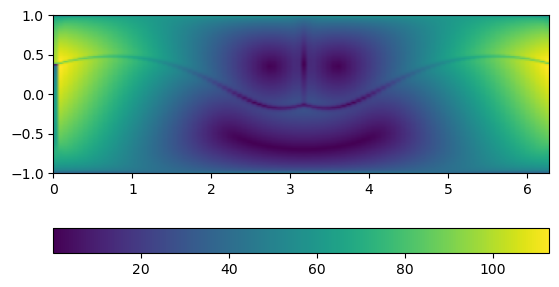

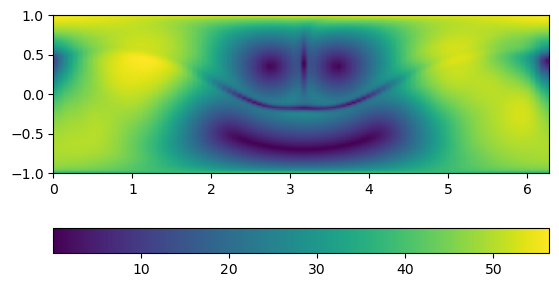

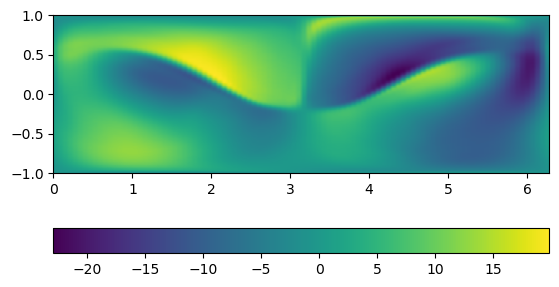

In [ ]:
# Plot exact score norm field at low time

plotScoreNormExact(.1)

# Plot score norm field from neural net, along with gauge component

plotScoreNormNet(smileyNetDirect, .1, plotGauge = True)

#### Test ODE

In [8]:
#sample at t=4 from uniform
nBatch = 100000
samples4 = sphere.normalize(np.random.normal(0,1,(nBatch,3)))

#linear spacing in log t
nSteps = 50
reverseTimes = []
for i in range(nSteps+1):
    a = i/nSteps
    tEff = np.exp((1-a)*np.log(t0 + 4) + a*np.log(t0))
    reverseTimes.append(tEff - t0)

  0%|          | 0/50 [00:00<?, ?it/s]

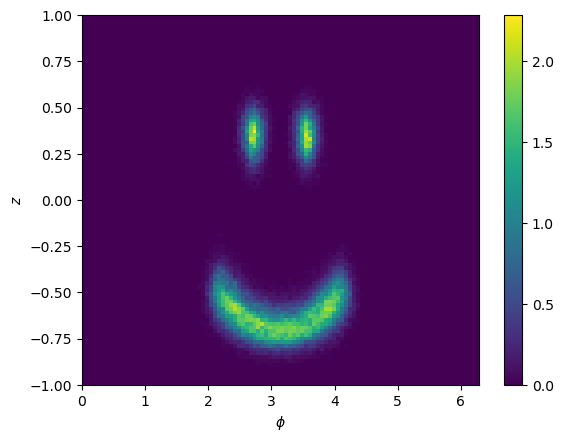

In [ ]:
from tqdm.notebook import tqdm

samples = samples4.copy()
for i in tqdm(range(len(reverseTimes)-1)):
    dt = reverseTimes[i]-reverseTimes[i+1]
    samples = sde.rk2Step(samples, reverseTimes[i], dt, lambda x, t : score_np(x, t, smileyNetDirect))

plotSphereHist(samples)

In [ ]:
nPhi = 100
print(f"TV distance of ODE (RK2), linear in u timesteps, from neural net trained on exact score")
print(f"nSteps: {nSteps},  nBatch: {nBatch},  nPhi: {nPhi}")
print(distHist(samples, nPhi))

TV distance of ODE (RK2), linear in u timesteps, from neural net trained on exact score
nSteps: 50,  nBatch: 100000,  nPhi: 100
0.08824428129123739


### Test model trained on conditional score

The previous output is for a model trained against the exact score, not the conditional score depending on `x0` at the initial time. This section tests smileyNet trained above with denoising score matching (DSM) for a small number of training steps (~12k at small batchSize and then 5k at batchSize = 25600).

  0%|          | 0/50 [00:00<?, ?it/s]

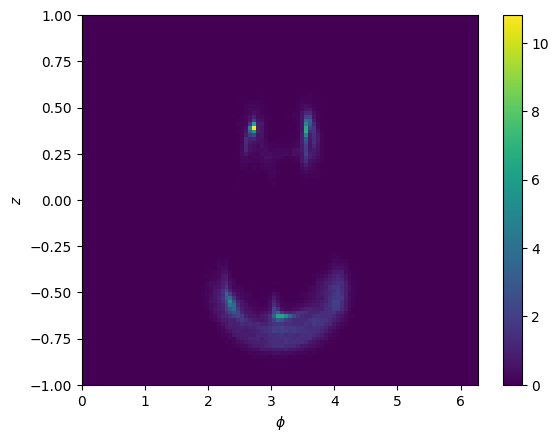

In [9]:
from tqdm.notebook import tqdm

samples = samples4.copy()
for i in tqdm(range(len(reverseTimes)-1)):
    dt = reverseTimes[i]-reverseTimes[i+1]
    samples = sde.rk2Step(samples, reverseTimes[i], dt, lambda x, t : score_np(x, t, smileyNet))

plotSphereHist(samples)

Can we do better with SDE methods?

  0%|          | 0/100 [00:00<?, ?it/s]

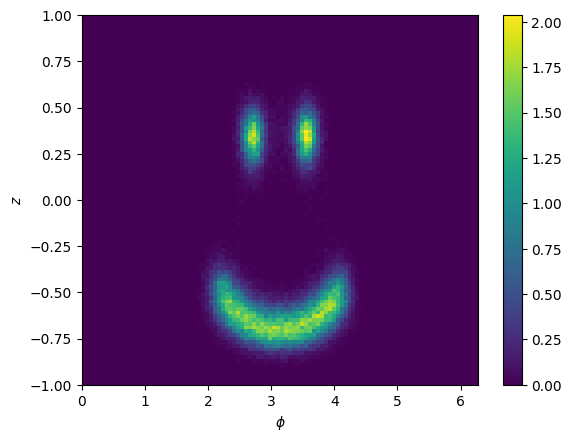

In [10]:
nSteps = 100
reverseTimes100 = []
for i in range(nSteps+1):
    a = i/nSteps
    tEff = np.exp((1-a)*np.log(t0 + 4) + a*np.log(t0))
    reverseTimes100.append(tEff - t0)

samples = samples4.copy()
for i in tqdm(range(len(reverseTimes100)-1)):
    dt = reverseTimes100[i]-reverseTimes100[i+1]
    samples = sde.eulerMaruyamaStep(samples, reverseTimes100[i], dt, lambda x, t : score_np(x, t, smileyNet))

plotSphereHist(samples)

In [11]:
nPhi = 100
print(f"TV distance of SDE, linear in u timesteps, from neural net trained on conditional score")
print(f"nSteps: {nSteps},  nBatch: {nBatch},  nPhi: {nPhi}")
print(distHist(samples, nPhi))

TV distance of SDE, linear in u timesteps, from neural net trained on conditional score
nSteps: 100,  nBatch: 100000,  nPhi: 100
0.08878213117217565


Euler-Maruyama for 100 steps using the DSM model does surprisingly well. It has a TV distance of 0.0888, which is only slightly higher than the 0.0882 obtained for a model trained on the exact marginal score and using RK2 sampling with the same number of score evaluations. For comparison, exact sampling from the distribution was shown above to have a TV distance of ~0.08 purely due to statistical effects.